# Swell and Wind Wave Conditions — Individual Mooring Line Force vs MBL

For each condition (steepness-line wind waves and swell grid), the maximum individual
mooring line force is shown as a percentage of MBL (1648 kN).

Both condition types share the same colour scale so they can be compared on a
physically meaningful basis. Dots are annotated with the governing line number.

Headings: 0°, 45°, 90°, 135°, 180°.

In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from pathlib import Path

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()
print(f'Working directory: {Path.cwd()}')

In [2]:
g = 9.81
TRANSIENT_S   = 400
DT            = 0.5
TRANSIENT_IDX = int(TRANSIENT_S / DT)
MBL_KN        = 1648.0

MOORING_ELEMS = [f'Mooring{i}' for i in range(1, 9)]

HEADINGS = ['0deg', '45deg', '90deg', '135deg', '180deg']
HEADING_LABELS = {'0deg': '0°', '45deg': '45°', '90deg': '90°', '135deg': '135°', '180deg': '180°'}

SWELL_FILES = {
    '0deg'  : {'static': '0deg/Swells/StaticResults_swells.h5',   'dynamic': '0deg/Swells/DynamicResults_swells.h5'},
    '45deg' : {'static': '45deg/Swells/StaticResults_swells.h5',  'dynamic': '45deg/Swells/DynamicResults_swells.h5'},
    '90deg' : {'static': '90deg/Swells/StaticResults_swells.h5',  'dynamic': '90deg/Swells/DynamicResults_swells.h5'},
    '135deg': {'static': '135deg/Swells/StaticResults_swells.h5', 'dynamic': '135deg/Swells/DynamicResults_swells.h5'},
    '180deg': {'static': '180deg/Swells/StaticResults_swells.h5', 'dynamic': '180deg/Swells/DynamicResults_swells.h5'},
}

_B = 'BerthedTanker_Catenary'
HS_VALUES = np.linspace(0.5, 3.5, 10)

LINES = {
    'HL7':  {'n':  7, 'base': f'{_B}/Run1',  'marker': 'o', 'label': '$H/\\lambda = 1/7$',  'lw': 7.0, 'ms': 180, 'n_cond': 9},
    'HL9':  {'n':  9, 'base': f'{_B}/Run2',  'marker': 's', 'label': '$H/\\lambda = 1/9$',  'lw': 6.5, 'ms': 160, 'n_cond': 9},
    'HL11': {'n': 11, 'base': f'{_B}/Run3',  'marker': 'D', 'label': '$H/\\lambda = 1/11$', 'lw': 6.0, 'ms': 140, 'n_cond': 9},
    'HL13': {'n': 13, 'base': f'{_B}/Run4',  'marker': '^', 'label': '$H/\\lambda = 1/13$', 'lw': 5.5, 'ms': 120, 'n_cond': 9},
    'HL15': {'n': 15, 'base': f'{_B}/Run5',  'marker': 'p', 'label': '$H/\\lambda = 1/15$', 'lw': 5.0, 'ms': 105, 'n_cond': 9},
    'HL17': {'n': 17, 'base': f'{_B}/Run6',  'marker': 'h', 'label': '$H/\\lambda = 1/17$', 'lw': 4.5, 'ms':  90, 'n_cond': 9},
    'HL19': {'n': 19, 'base': f'{_B}/Run7',  'marker': '*', 'label': '$H/\\lambda = 1/19$', 'lw': 4.0, 'ms':  75, 'n_cond': 9},
    'HL21': {'n': 21, 'base': f'{_B}/Run8',  'marker': 'v', 'label': '$H/\\lambda = 1/21$', 'lw': 3.5, 'ms':  62, 'n_cond': 9},
    'HL23': {'n': 23, 'base': f'{_B}/Run9',  'marker': '<', 'label': '$H/\\lambda = 1/23$', 'lw': 3.2, 'ms':  55, 'n_cond': 9},
    'HL25': {'n': 25, 'base': f'{_B}/Run10', 'marker': '>', 'label': '$H/\\lambda = 1/25$', 'lw': 2.9, 'ms':  48, 'n_cond': 8},
    'HL27': {'n': 27, 'base': f'{_B}/Run11', 'marker': 'P', 'label': '$H/\\lambda = 1/27$', 'lw': 2.6, 'ms':  42, 'n_cond': 7},
    'HL29': {'n': 29, 'base': f'{_B}/Run12', 'marker': 'X', 'label': '$H/\\lambda = 1/29$', 'lw': 2.3, 'ms':  36, 'n_cond': 7},
}

for cfg in LINES.values():
    nc   = cfg['n_cond']
    Hs_v = HS_VALUES[:nc]
    Tp_v = np.sqrt(Hs_v * 2 * np.pi * cfg['n'] / g)
    cfg['cond_params'] = {i+1: (round(float(hs), 2), round(float(tp), 2))
                          for i, (hs, tp) in enumerate(zip(Hs_v, Tp_v))}

VMIN, VMAX = 0, 100  # % of MBL

In [3]:
# Wind wave individual mooring max force per condition from CSV
df_moor = pd.read_csv('mooring_per_line.csv')

idx = df_moor.groupby(['heading', 'line', 'cond_num', 'Hs', 'Tp'])['dyn_max_kN'].idxmax()
ww_force = df_moor.loc[idx, ['heading', 'line', 'cond_num', 'Hs', 'Tp', 'elem', 'dyn_max_kN']].copy()
ww_force = ww_force.rename(columns={'dyn_max_kN': 'max_force_kN'})
ww_force['gov_num']  = ww_force['elem'].str.replace('Mooring', '', regex=False)
ww_force['pct_mbl']  = ww_force['max_force_kN'] / MBL_KN * 100.0

print('Wind wave force rows:', len(ww_force))
print(ww_force.head())

Wind wave force rows: 515
    heading  line  cond_num    Hs    Tp      elem  max_force_kN gov_num  \
148    0deg  HL11         1  0.50  1.88  Mooring5      164.2367       5   
156    0deg  HL11         2  0.83  2.42  Mooring5      166.3148       5   
160    0deg  HL11         3  1.17  2.87  Mooring1      175.0213       1   
168    0deg  HL11         4  1.50  3.25  Mooring1      209.4187       1   
176    0deg  HL11         5  1.83  3.59  Mooring1      236.4431       1   

       pct_mbl  
148   9.965819  
156  10.091917  
160  10.620225  
168  12.707445  
176  14.347275  


In [4]:
HS_VALS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
TP_VALS = list(range(8, 21))

cases = pd.DataFrame(
    [(hs, tp) for hs in HS_VALS for tp in TP_VALS],
    columns=['Hs', 'Tp']
)
cases.insert(0, 'condition', cases.index + 1)


def load_swell_forces(heading_key):
    cfg          = SWELL_FILES[heading_key]
    static_path  = NOTEBOOK_DIR / cfg['static']
    dynamic_path = NOTEBOOK_DIR / cfg['dynamic']
    if not static_path.exists() or not dynamic_path.exists():
        return None

    records = []
    try:
        with h5py.File(static_path, 'r') as sf, h5py.File(dynamic_path, 'r') as dfh:
            root_s = list(sf.keys())[0]
            root_d = list(dfh.keys())[0]
            sw_s   = sf[root_s]['Swells']
            sw_d   = dfh[root_d]['Swells']
            keys   = sorted(sw_s.keys(), key=lambda x: int(x.rsplit('_', 1)[-1]))
            for k in keys:
                n = int(k.rsplit('_', 1)[-1])
                try:
                    grp_s = sw_s[k]['Static']['Tanker']
                    grp_d = sw_d[k]['Dynamic']['Tanker']['Positioning system force']
                except KeyError as e:
                    print(f'  WARNING: {heading_key} condition {n} missing key {e} — skipped')
                    continue

                results = []
                for m in MOORING_ELEMS:
                    s_m = float(grp_s[m]['FTotal'][()])
                    if s_m > 1000.0:
                        ts_m = grp_d[f'TotalForce_{m}'][TRANSIENT_IDX:]
                        results.append((float(np.max(ts_m)) / 1000.0, m))  # N → kN
                if results:
                    max_force_kN, gov_mooring = max(results, key=lambda x: x[0])
                else:
                    max_force_kN, gov_mooring = np.nan, ''

                records.append({'condition': n, 'max_force_kN': max_force_kN,
                                'gov_mooring': gov_mooring})
    except Exception as e:
        print(f'  ERROR loading {heading_key}: {e}')
        return None

    df = pd.DataFrame(records).merge(cases, on='condition', how='left')
    df['pct_mbl'] = df['max_force_kN'] / MBL_KN * 100.0
    return df


swell_data = {}
for h in HEADINGS:
    df = load_swell_forces(h)
    if df is not None:
        swell_data[h] = df
        print(f"{h}: {len(df)} conditions  "
              f"max force {df.max_force_kN.max():.1f} kN  "
              f"({df.pct_mbl.max():.1f}% MBL)")
    else:
        print(f"{h}: no data")

available = [h for h in HEADINGS if h in swell_data]

0deg: 78 conditions  max force 357.1 kN  (21.7% MBL)
45deg: 78 conditions  max force 1716.9 kN  (104.2% MBL)
90deg: 78 conditions  max force 1885.9 kN  (114.4% MBL)
135deg: 78 conditions  max force 1501.7 kN  (91.1% MBL)
180deg: 78 conditions  max force 368.9 kN  (22.4% MBL)


In [5]:
cmap = plt.cm.RdYlGn_r
norm = Normalize(vmin=VMIN, vmax=VMAX, clip=True)

sweep = np.linspace(0.3, 21, 800)

line_handles = [
    Line2D([0], [0], color='grey', lw=cfg['lw'], label=cfg['label'],
           marker='o', markerfacecolor='grey', markeredgecolor='black', markersize=5)
    for cfg in LINES.values()
]
swell_handle = Line2D([0], [0], linestyle='none', marker='D',
                      markerfacecolor='white', markeredgecolor='black',
                      markersize=6, label='Swells')


def make_lc(x, y, val_arr, lw, norm):
    pts  = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap=cmap, norm=norm,
                          linewidth=lw, alpha=0.85, zorder=3)
    lc.set_array((val_arr[:-1] + val_arr[1:]) / 2)
    return lc

## Individual Mooring Line Force / MBL — Wind Waves + Swells

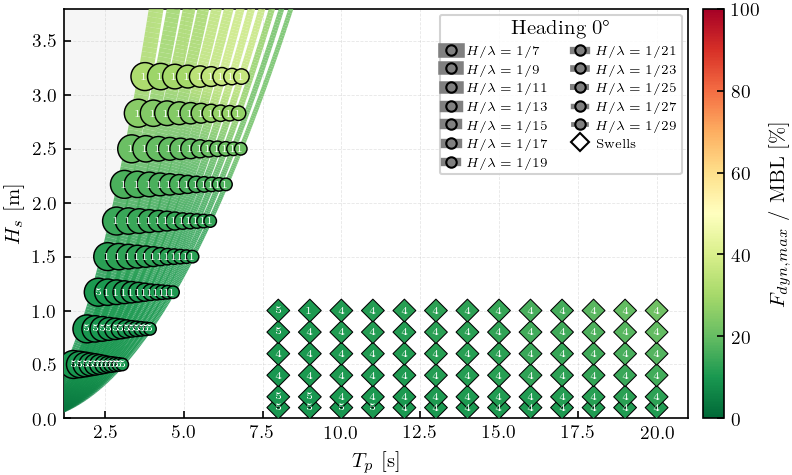

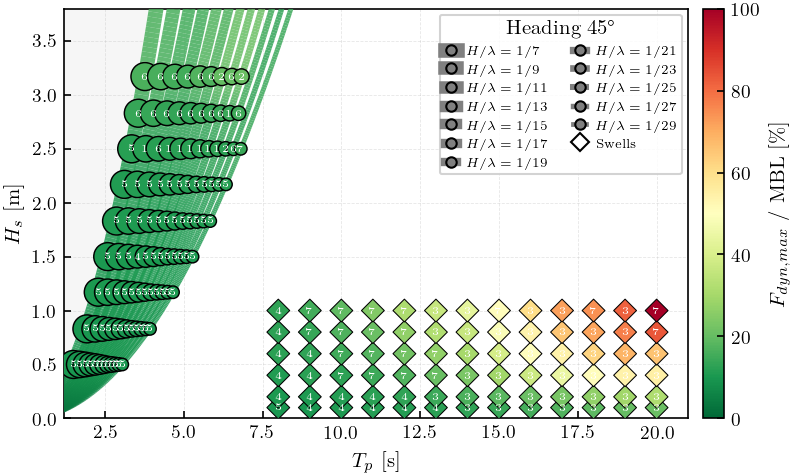

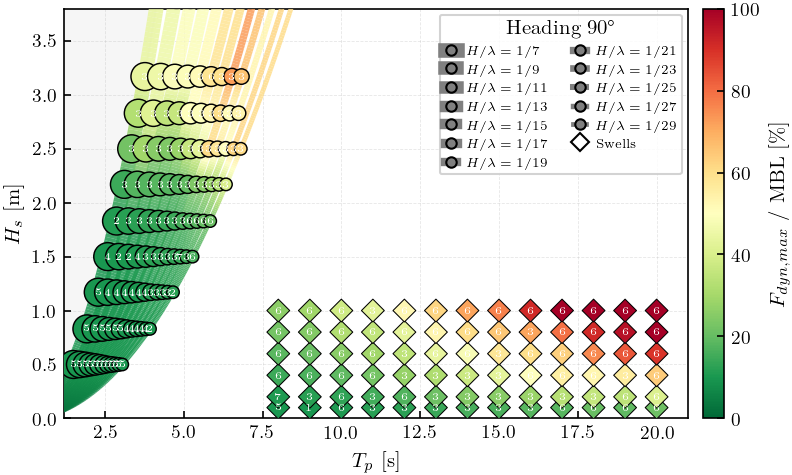

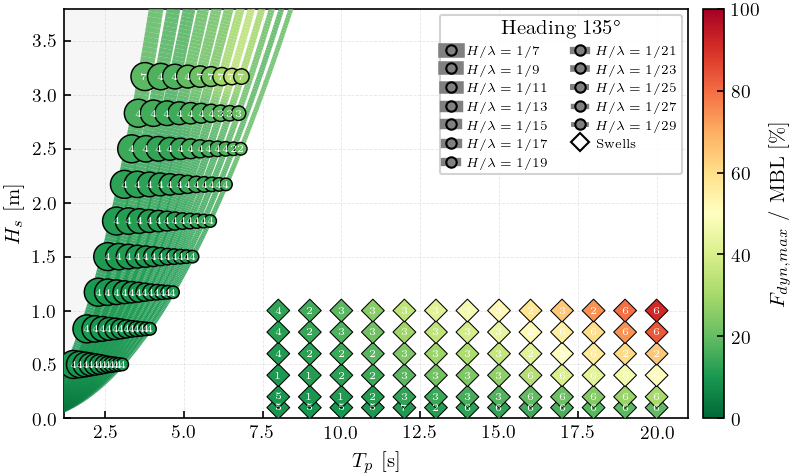

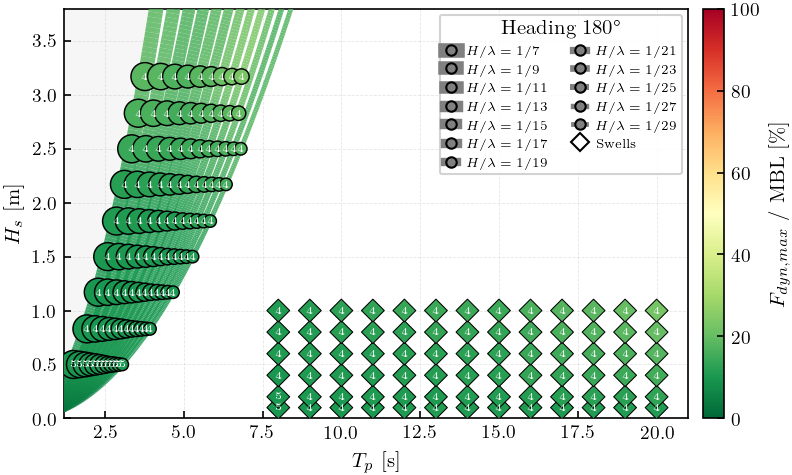

In [6]:
for h in HEADINGS:
    sub_ww = ww_force[ww_force.heading == h]
    fig, ax = plt.subplots(figsize=full())

    ax.fill_between(sweep, g * sweep**2 / (2 * np.pi * 7), 10,
                    color='lightgrey', alpha=0.2, zorder=0)

    sc_ref = None
    for line_name, cfg in LINES.items():
        y_curve  = g * sweep**2 / (2 * np.pi * cfg['n'])
        sub      = sub_ww[sub_ww.line == line_name]
        val_dict = dict(zip(sub.cond_num, sub.pct_mbl))
        num_dict = dict(zip(sub.cond_num, sub.gov_num))
        conds    = sorted(cfg['cond_params'])

        pts_x   = np.array([cfg['cond_params'][c][1] for c in conds])
        pts_y   = np.array([cfg['cond_params'][c][0] for c in conds])
        val_pts = np.array([val_dict.get(c, np.nan) for c in conds])

        val_interp = np.interp(
            sweep,
            np.concatenate([[sweep[0]], pts_x]),
            np.concatenate([[0.0], val_pts]),
        )
        ax.add_collection(make_lc(sweep, y_curve, val_interp, cfg['lw'], norm))
        sc = ax.scatter(pts_x, pts_y, c=val_pts, cmap=cmap, norm=norm,
                        s=cfg['ms'], zorder=5, edgecolors='black', linewidths=0.7, marker='o')
        if sc_ref is None:
            sc_ref = sc

        for c, x, y in zip(conds, pts_x, pts_y):
            num = num_dict.get(c, '')
            if num:
                ax.text(x, y, num, ha='center', va='center',
                        fontsize=5, fontweight='bold', color='white', zorder=6)

    # Swell dots — diamond markers, annotated with governing line number
    if h in swell_data:
        sw = swell_data[h]
        ax.scatter(sw['Tp'], sw['Hs'], c=sw['pct_mbl'], cmap=cmap, norm=norm,
                   s=60, marker='D', edgecolors='black', linewidths=0.5, zorder=7)
        for _, row in sw.iterrows():
            if not np.isnan(row['max_force_kN']):
                num = str(row['gov_mooring']).replace('Mooring', '')
                ax.text(row['Tp'], row['Hs'], num, ha='center', va='center',
                        fontsize=5, fontweight='bold', color='white', zorder=8)

    ax.set_xlabel('$T_p$ [s]')
    ax.set_ylabel('$H_s$ [m]')
    ax.set_xlim(1.2, 21)
    ax.set_ylim(0.0, 3.8)
    ax.grid(True, alpha=0.3)
    ax.legend(handles=line_handles + [swell_handle], fontsize=6,
              loc='upper right', ncol=2, handlelength=1.0,
              borderaxespad=0.5, framealpha=0.85, title=f'Heading {HEADING_LABELS[h]}')
    cb = fig.colorbar(sc_ref, ax=ax, pad=0.02)
    cb.set_label(r'$F_{dyn,max}$ / MBL [\%]')
    plt.tight_layout()
    save(fig, f'swell_force_mbl_{h}')
    plt.show()

## Individual Mooring Line Force / MBL — Swells only (heatmap)

Swell-only version of the wind-sea MBL utilisation heatmaps (`daf_mooring_mbl_*`), separated out
from the combined wind-wave + swell scatter above. One figure per heading on the swell
$H_s$–$T_p$ grid; colour = governing individual mooring line $F_{dyn,max}$ as a percentage of
MBL (1648 kN), on the same RdYlGn 0–100% scale as the wind-sea heatmaps for direct comparison.
Cells exceeding 100% show the true value while the colour saturates at the red end.

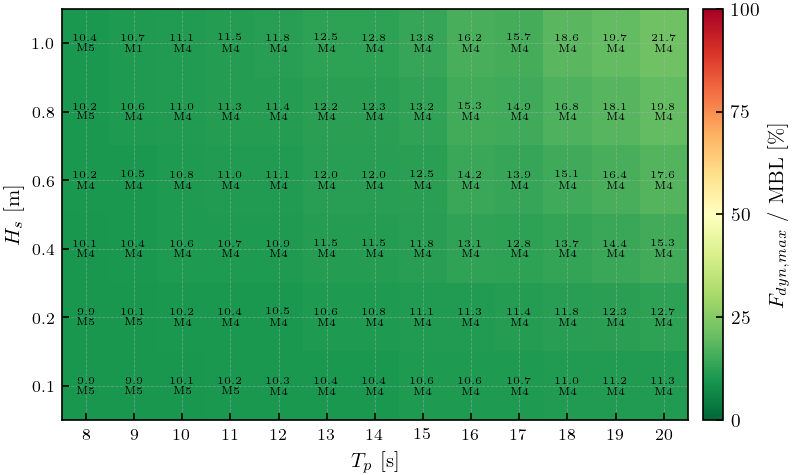

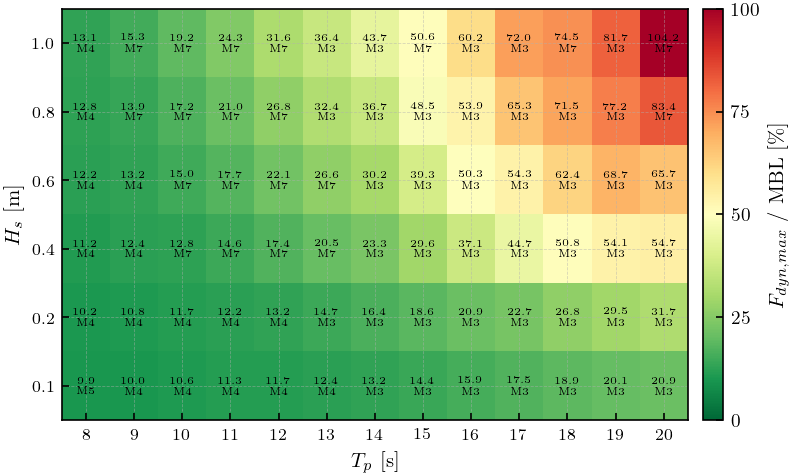

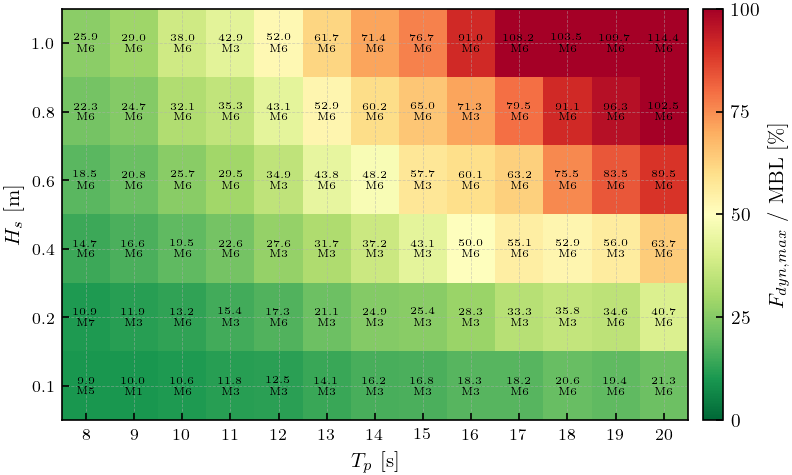

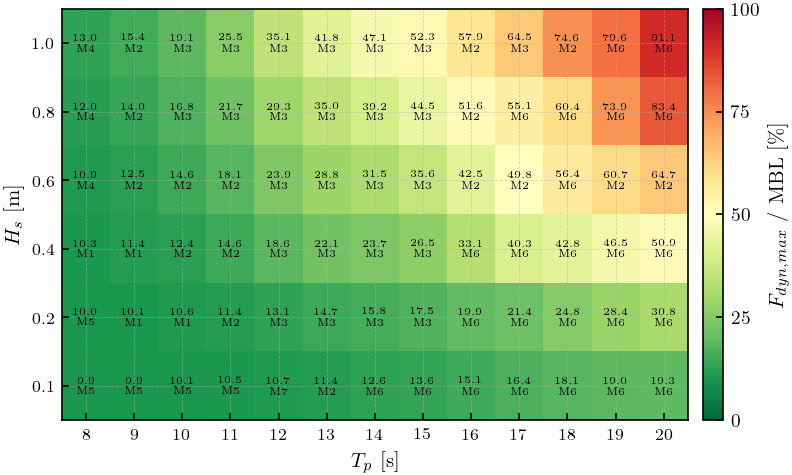

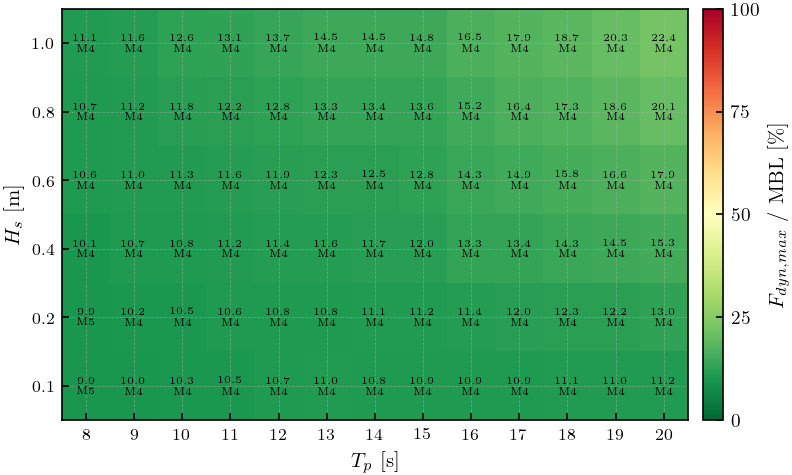

In [7]:
from matplotlib.colors import TwoSlopeNorm

# Swell-only MBL utilisation heatmap — same style/scale as the wind-sea heatmaps (daf_mooring_mbl_*).
# Rows = Hs (0.1 bottom -> 1.0 top), cols = Tp (8 -> 20); colour = governing individual mooring
# line F_dyn,max as % of MBL (governing line = highest peak dynamic force over all timeseries).
# One figure per heading. Values above 100% (MBL exceeded) keep their true number; the colour
# saturates at the red end. Cells are annotated with the governing line number.
mbl_norm = TwoSlopeNorm(vmin=0.0, vcenter=50.0, vmax=100.0)
cmap     = plt.cm.RdYlGn_r

for h in available:
    sw  = swell_data[h]
    mat = np.full((len(HS_VALS), len(TP_VALS)), np.nan)
    ann = np.full((len(HS_VALS), len(TP_VALS)), '', dtype=object)
    for _, row in sw.iterrows():
        if pd.isna(row['Hs']) or pd.isna(row['Tp']) or pd.isna(row['pct_mbl']):
            continue
        r = HS_VALS.index(row['Hs'])
        c = TP_VALS.index(int(row['Tp']))
        mat[r, c] = row['pct_mbl']
        ann[r, c] = str(row['gov_mooring']).replace('Mooring', 'M')

    fig, ax = plt.subplots(figsize=full())
    im = ax.imshow(mat, aspect='auto', norm=mbl_norm, cmap=cmap,
                   origin='lower', interpolation='none')
    ax.set_xticks(range(len(TP_VALS)))
    ax.set_xticklabels([str(t) for t in TP_VALS], fontsize=8)
    ax.set_yticks(range(len(HS_VALS)))
    ax.set_yticklabels([f'{hs:.1f}' for hs in HS_VALS], fontsize=8)
    ax.set_xlabel('$T_p$ [s]')
    ax.set_ylabel('$H_s$ [m]')
    for r in range(len(HS_VALS)):
        for c in range(len(TP_VALS)):
            v = mat[r, c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.1f}%\n{ann[r, c]}', ha='center', va='center', fontsize=5)
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(r'$F_{dyn,max}$ / MBL [\%]')
    cb.set_ticks([0, 25, 50, 75, 100])
    plt.tight_layout()
    save(fig, f'swell_mooring_mbl_heatmap_{h}')
    plt.show()